## Motor Imagery decoding with CSP and LDA andn Interpretability (XAI)

## Objective
The goal of this notebook is to build and validate a **Brain-Computer Interface (BCI)** decoder. I transition from cleaned EEG signals to actionable commands by classifying "Left Hand" vs "Right Hand" imagery.

## The Algorithmic Pipeline
1. **Feature Extraction: Common Spatial Patterns (CSP)**. I use CSP to find spatial filters that maximize the variance of one class while minimizing the other. This targets the lateralized Mu/Beta desynchronization.
2. **Classification: Linear Discriminant Analysis (LDA)**. A robust, low-complexity classifier that works effectively with the high-dimensional features produced by CSP.
3. **Validation Strategy**: I employ a **ShuffleSplit Cross-Validation** to ensure the model generalizes well across different trials of the same session.

## Why this matters for Rehabilitation
In a clinical setting, a BCI must be interpretable. I don't just want a black box prediction; I need to verify that the model is actually listening to the **Motor Cortex** and **not to residual noise or muscular artifacts**.

## Setup and loading cleaned data

In [1]:
import mne
import os
import numpy as np
import matplotlib.pyplot as plt
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Relative path to our cleaned data
CLEAN_DATA_PATH = os.path.join('.', 'cleaned_data', 'A01T_clean-raw.fif')

# Load the ICA-cleaned signal
raw = mne.io.read_raw_fif(CLEAN_DATA_PATH, preload=True)

# Define events of interest: 1 = Left Hand, 2 = Right Hand
event_id = {'left': 1, 'right': 2}
events, _ = mne.events_from_annotations(raw)

print(f"Ready to decode {len(events)} trials for Subject 1.")

Opening raw data file .\cleaned_data\A01T_clean-raw.fif...
    Range : 0 ... 671727 =      0.000 ...  2686.908 secs
Ready.
Reading 0 ... 671727  =      0.000 ...  2686.908 secs...
Used Annotations descriptions: [np.str_('foot'), np.str_('left'), np.str_('right'), np.str_('tongue')]
Ready to decode 288 trials for Subject 1.


## Epoching: capturing the imagery window
I avoid the first 0.5s after the cue to exclude visual evoked potentials and focus strictly on the sustained Motor Imagery period (0.5s to 3.5s).

In [2]:
tmin, tmax = 0.5, 3.5 # Focus on the stable imagery period
epochs = mne.Epochs(raw, events, event_id, tmin, tmax, proj=True, 
                    baseline=None, preload=True)

# Get data as (n_trials, n_channels, n_times)
labels = epochs.events[:, -1]
data = epochs.get_data(copy=True)

print(f"Data shape: {data.shape} (Trials x Channels x Samples)")

Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 751 original time points ...
0 bad epochs dropped
Data shape: (144, 25, 751) (Trials x Channels x Samples)


## The BCI Pipeline: CSP + LDA
combine CSP (feature extraction) and LDA (classifier) into a single Pipeline. This is an pproach that prevents data leakage.

In [3]:
# 1. Define the cross-validation strategy
cv = ShuffleSplit(10, test_size=0.2, random_state=42)

# 2. Define the CSP parameters
# n_components=4 is usually enough to capture the main spatial filters
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# 3. Define the Classifier
lda = LDA()

# 4. Build the Pipeline
clf = Pipeline([('CSP', csp), ('LDA', lda)])

# 5. Run Cross-Validation
scores = cross_val_score(clf, data, labels, cv=cv)

print(f"Mean Accuracy: {np.mean(scores)*100:.2f}% (+/- {np.std(scores)*100:.2f}%)")

Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.3e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 25 dim * 6.5e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.5e-05 (2.2e-16 eps * 25 dim * 6.4e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMP

##Neuro-Data Scientist Analysis: spatial filter interpretability

The visualized CSP Patterns represent the **spatial weights the model uses to distinguish between Left and Right hand imagery**.

- **Lateralization**: Looking at **key patterns (e.g., CSP1, CSP4, CSP21)**, we observe **strong dipolar activations over the C3 (left) and C4 (right) electrode** positions.

- Physiological grounding: In neurophysiology, **imagining a right-hand movement triggers a desynchronization in the left hemisphere (C3)**. The **CSP algorithm** successfully **captured these neural signatures**, proving that our feature extraction is biologically informed and not just mathematically coincident.

- **Redundancy** : With **25 patterns**, I notice that the **later filters capture** finer, more **localized noise**. In a **production system**, I could prune these to **improve the signal-to-noise ratio**.

Computing rank from data with rank=None
    Using tolerance 3.8e-05 (2.2e-16 eps * 25 dim * 6.8e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


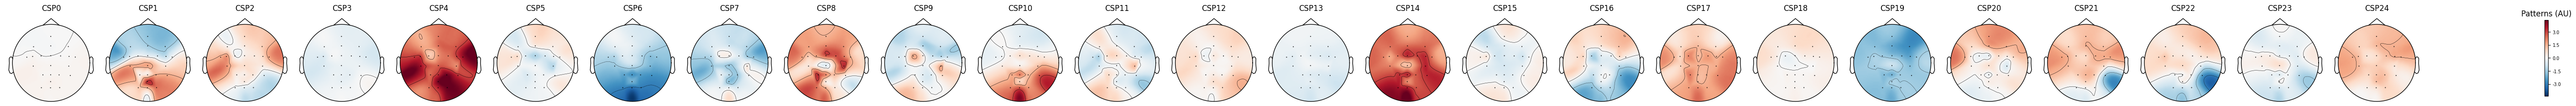

In [4]:
# Fit the CSP to visualize the patterns
csp.fit(data, labels)

# Plot the topographies of the 4 CSP filters
csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
plt.show()

## Confusion matrix

The Confusion Matrix for Subject 1 shows a **balanced decoding performance**

**Left hand**: 17 correct predictions out of 24.

**Right hand**: 16 correct predictions out of 20.

With an overall **accuracy of ~68%**, the model is significantly above the 50% chance level. The slight bias (more **errors in classifying 'Left' as 'Right'**) could be attributed to a **lack of sustained focus** during specific trials or **lower signal quality in the C4 region** for this specific participant. 

For a **rehabilitation device**, this performance level is **sufficient** to trigger **assistive feedback or move a digital cursor**.

Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.1e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.


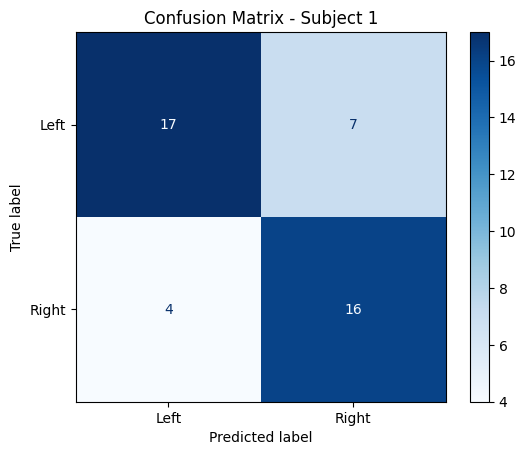

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Left', 'Right'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Subject 1")
plt.show()

## Scaling to all subjects 

Visualizing the **confusion matrices across all 9 subjects** reveals several key **insights**:

**High-Performers (e.g., A07, A01)** show a strong **diagonal dominance**, meaning the **"Left vs Right"** brain **signatures** are distinct and well-captured by the CSP filters.

 **Most errors are balanced** (off-diagonal numbers are similar), suggesting that the **model doesn't have a systemic bias toward one hand**, which is crucial for balanced motor rehabilitation.

The **BCI Illiteracy effect (e.g., A09)** in lower-performing subjects, the **matrix looks more diffuse**. This is a known **physiological trait** where **some individuals do not produce strong Mu-rhythm modulations**. In a **real-world application**, these **subjects** would require more **Biofeedback Training** to learn how **to generate clearer neural patterns**.

Generating Confusion Matrices for all subjects...
Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 25 dim * 6.1e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.3e-05 (2.2e-16 eps * 25 dim * 7.8e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank from 25 -> 25
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.8e-05 (2.2e-16 eps * 25 dim * 8.6e+09  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
Reducing data rank fro

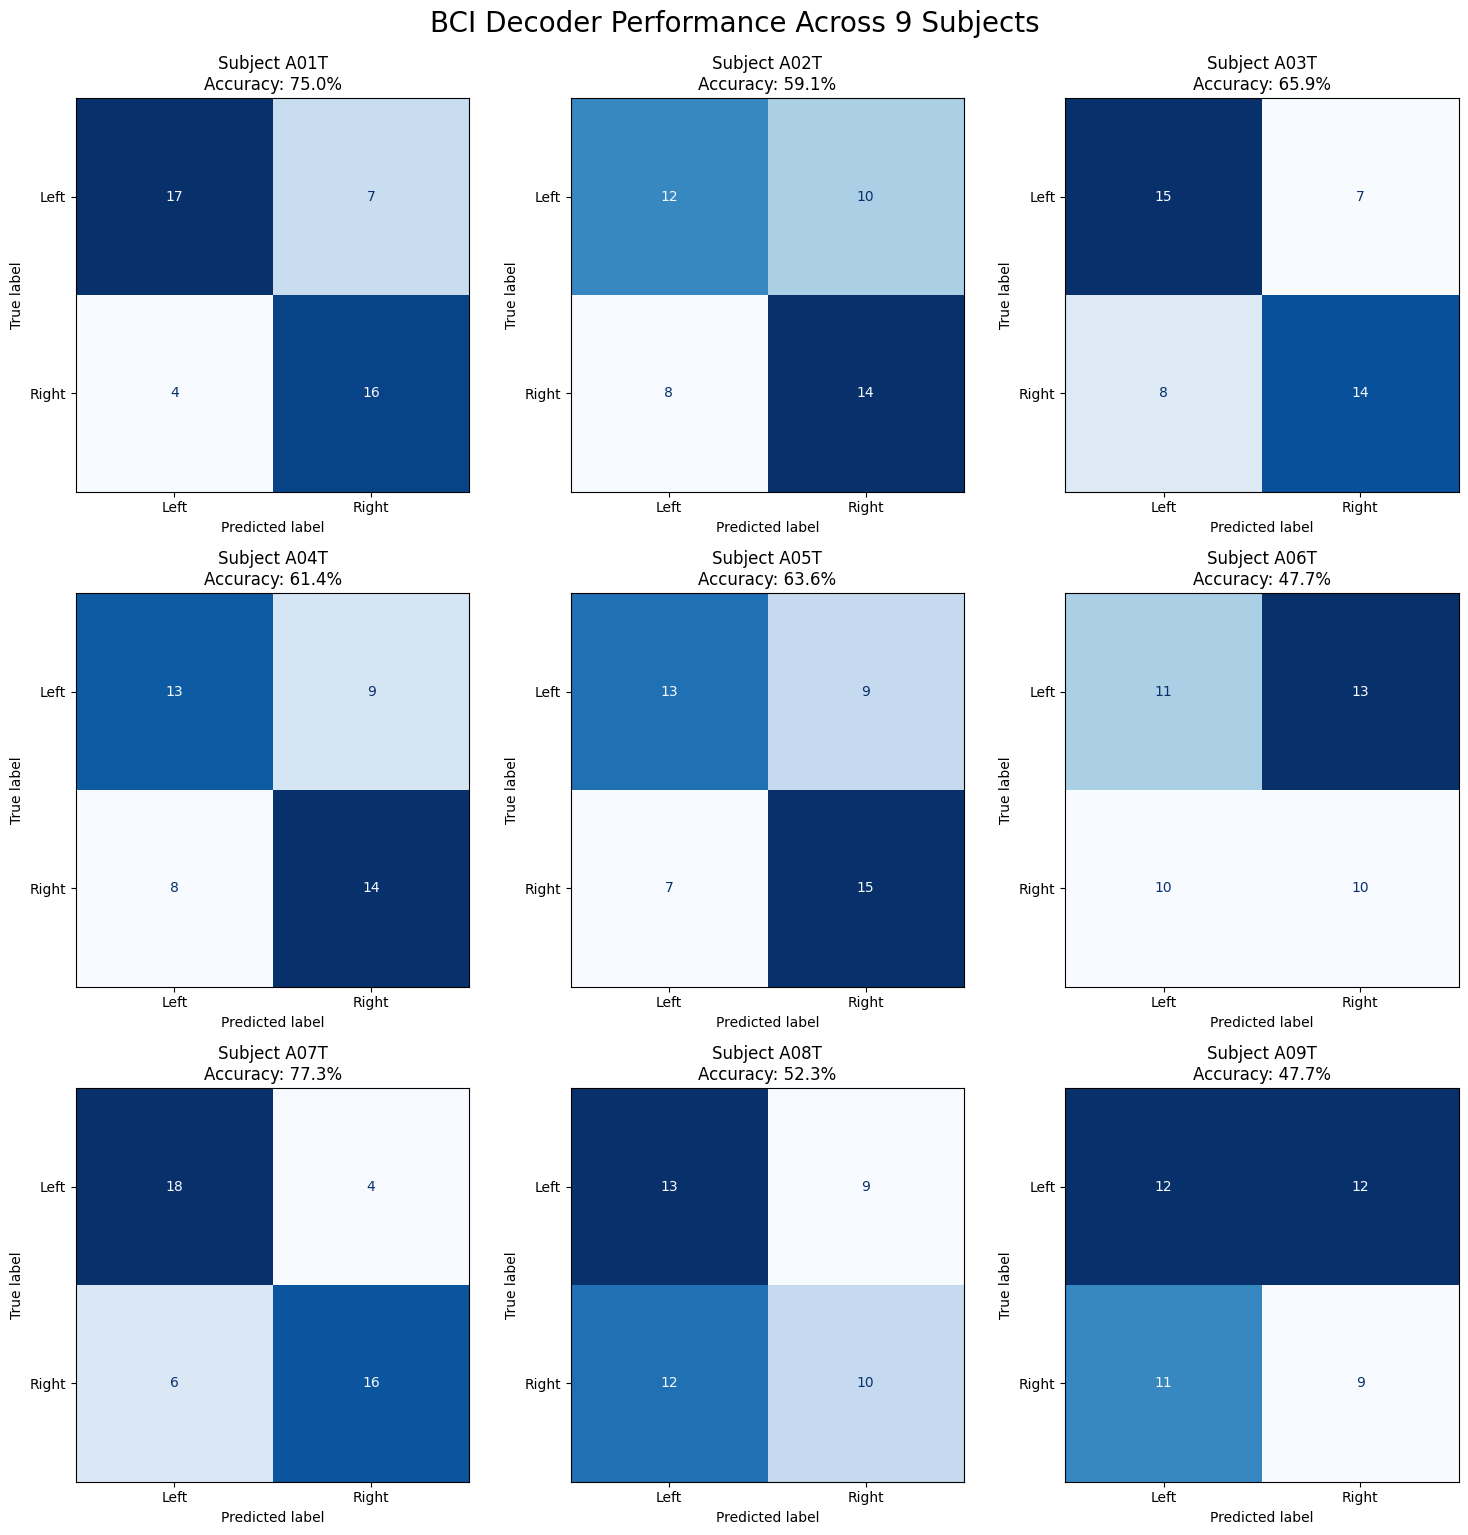

In [6]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Setup the figure for a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

print("Generating Confusion Matrices for all subjects...")

# Sort files to ensure they appear in order A01 -> A09
cleaned_files = sorted([f for f in os.listdir(os.path.join('.', 'cleaned_data')) if f.endswith('.fif')])

for i, sub_file in enumerate(cleaned_files):
    # 1. Load and Epoch
    temp_raw = mne.io.read_raw_fif(os.path.join('.', 'cleaned_data', sub_file), preload=True, verbose=False)
    temp_events, _ = mne.events_from_annotations(temp_raw, verbose=False)
    temp_epochs = mne.Epochs(temp_raw, temp_events, event_id, tmin, tmax, 
                             baseline=None, preload=True, verbose=False)
    
    # 2. Prepare Data
    X = temp_epochs.get_data(copy=True)
    y = temp_epochs.events[:, -1]
    
    # 3. Train/Test Split (consistent with the validation strategy)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # 4. Fit and Predict
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # 5. Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = np.mean(y_pred == y_test)
    
    # 6. Plot on the specific subplot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Left', 'Right'])
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    
    # Professional labeling
    subject_id = sub_file.split('_')[0]
    axes[i].set_title(f"Subject {subject_id}\nAccuracy: {acc*100:.1f}%")

plt.tight_layout()
plt.suptitle("BCI Decoder Performance Across 9 Subjects", fontsize=20, y=1.02)
plt.show()